# Set-Theoretic Operations On 2D Objects

This notebook demonstrates union, intersection, difference, and symmetric difference for 2D geometric objects in `EuclideanPlaneSpace`.


In [1]:
from pathlib import Path
import sys
import math

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from geo import Ball, Cube, EuclideanPlaneSpace, FloatPoint, RiemannianGeometricObject


In [2]:
def membership_grid(obj, xlim=(-2.5, 2.5), ylim=(-2.2, 2.2), size=240):
    xs = np.linspace(xlim[0], xlim[1], size)
    ys = np.linspace(ylim[0], ylim[1], size)
    grid = np.zeros((size, size), dtype=float)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            grid[j, i] = 1.0 if FloatPoint(x, y) in obj else 0.0
    return xs, ys, grid


def plot_object(ax, obj, title, xlim=(-2.5, 2.5), ylim=(-2.2, 2.2), color='#4c78a8'):
    xs, ys, grid = membership_grid(obj, xlim=xlim, ylim=ylim)
    ax.imshow(
        grid,
        extent=(xs[0], xs[-1], ys[0], ys[-1]),
        origin='lower',
        cmap='Blues',
        alpha=0.88,
        interpolation='nearest',
        vmin=0.0,
        vmax=1.0,
    )
    if np.any(grid):
        ax.contour(xs, ys, grid, levels=[0.5], colors=[color], linewidths=2.2)
    ax.axhline(0.0, color="#cccccc", linewidth=0.8, zorder=0)
    ax.axvline(0.0, color="#cccccc", linewidth=0.8, zorder=0)
    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.18)


def wrap(space, charted, name):
    return RiemannianGeometricObject.from_charted(space, charted, name=name)


## Example 1: disk and square

Both operands are bounded, so the boolean operations produce especially clear planar regions.


In [3]:
plane = EuclideanPlaneSpace(name='plane')
disk = wrap(plane, Ball(FloatPoint(-0.35, 0.0), 1.45), name='disk')
square = wrap(plane, Cube(FloatPoint(0.65, 0.0), 1.1), name='square')

disk_union_square = disk | square
disk_intersection_square = disk & square
disk_minus_square = disk - square
disk_xor_square = disk ^ square

print('disk contains origin:', FloatPoint(0.0, 0.0) in disk)
print('square contains origin:', FloatPoint(0.0, 0.0) in square)
print('intersection contains origin:', FloatPoint(0.0, 0.0) in disk_intersection_square)
print('difference contains (1.4, 0):', FloatPoint(1.4, 0.0) in disk_minus_square)


disk contains origin: True
square contains origin: True
intersection contains origin: True
difference contains (1.4, 0): False


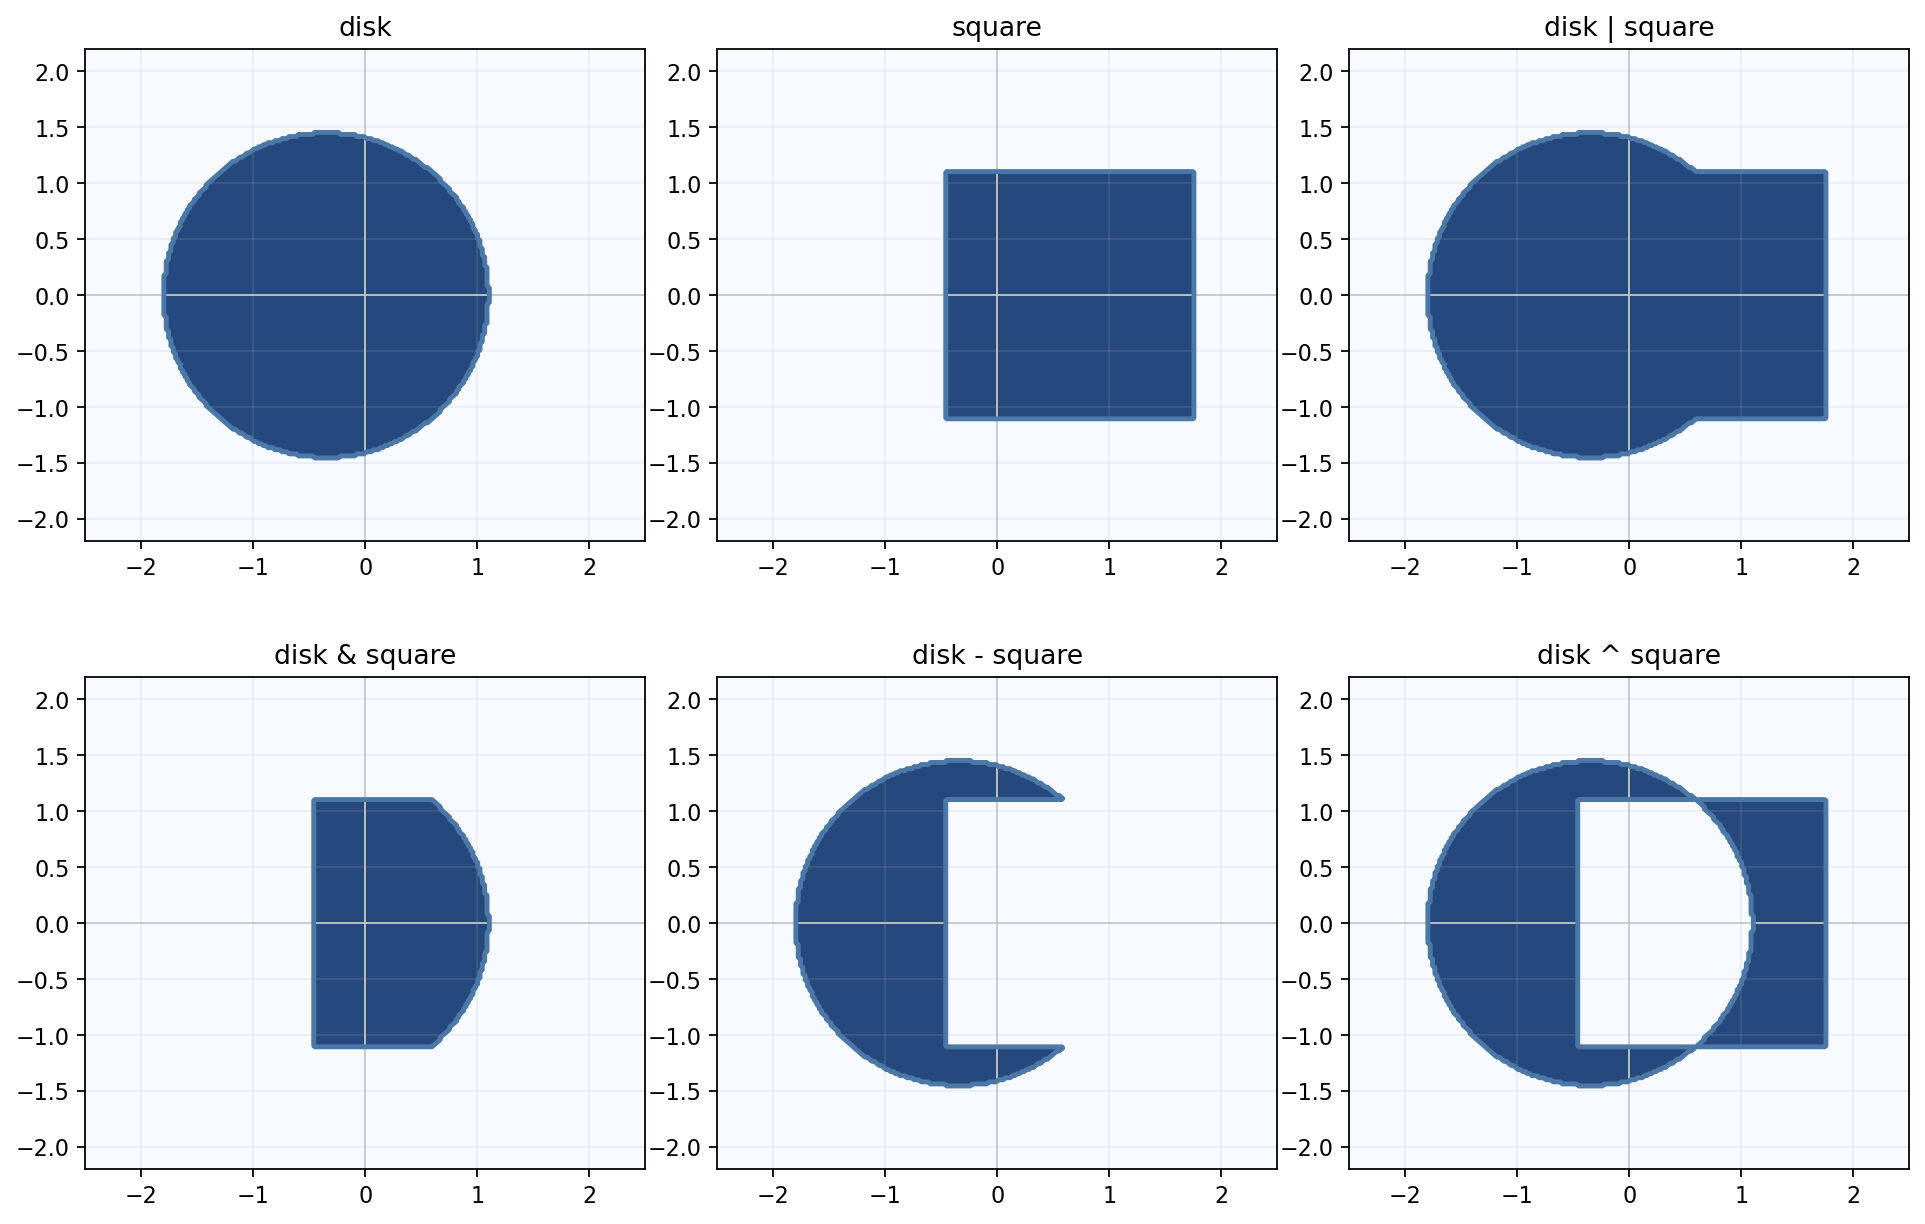

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
plot_object(axes[0, 0], disk, 'disk')
plot_object(axes[0, 1], square, 'square')
plot_object(axes[0, 2], disk_union_square, 'disk | square')
plot_object(axes[1, 0], disk_intersection_square, 'disk & square')
plot_object(axes[1, 1], disk_minus_square, 'disk - square')
plot_object(axes[1, 2], disk_xor_square, 'disk ^ square')
fig.tight_layout()
fig


## Example 2: angle and clipped half-plane

Here the operands are first clipped by a disk-shaped window, which makes the set-theoretic result finite and easy to compare.


In [5]:
window = wrap(plane, Ball(FloatPoint(0.0, 0.0), 2.0), name='window')
angle = plane.angle(FloatPoint(-1.45, -1.1), 0.05, math.pi / 2.35, name='angle')
half_plane = plane.half_plane((0.0, 1.0), offset=-0.15, name='upper-half-plane')

clipped_angle = angle & window
clipped_half_plane = half_plane & window
window_union = clipped_angle | clipped_half_plane
window_intersection = clipped_angle & clipped_half_plane
window_difference = clipped_angle - clipped_half_plane
window_xor = clipped_angle ^ clipped_half_plane

print('clipped angle contains (-1, -0.5):', FloatPoint(-1.0, -0.5) in clipped_angle)
print('clipped half-plane contains (0, -1):', FloatPoint(0.0, -1.0) in clipped_half_plane)
print('xor contains (1, 1):', FloatPoint(1.0, 1.0) in window_xor)


clipped angle contains (-1, -0.5): True
clipped half-plane contains (0, -1): False
xor contains (1, 1): False


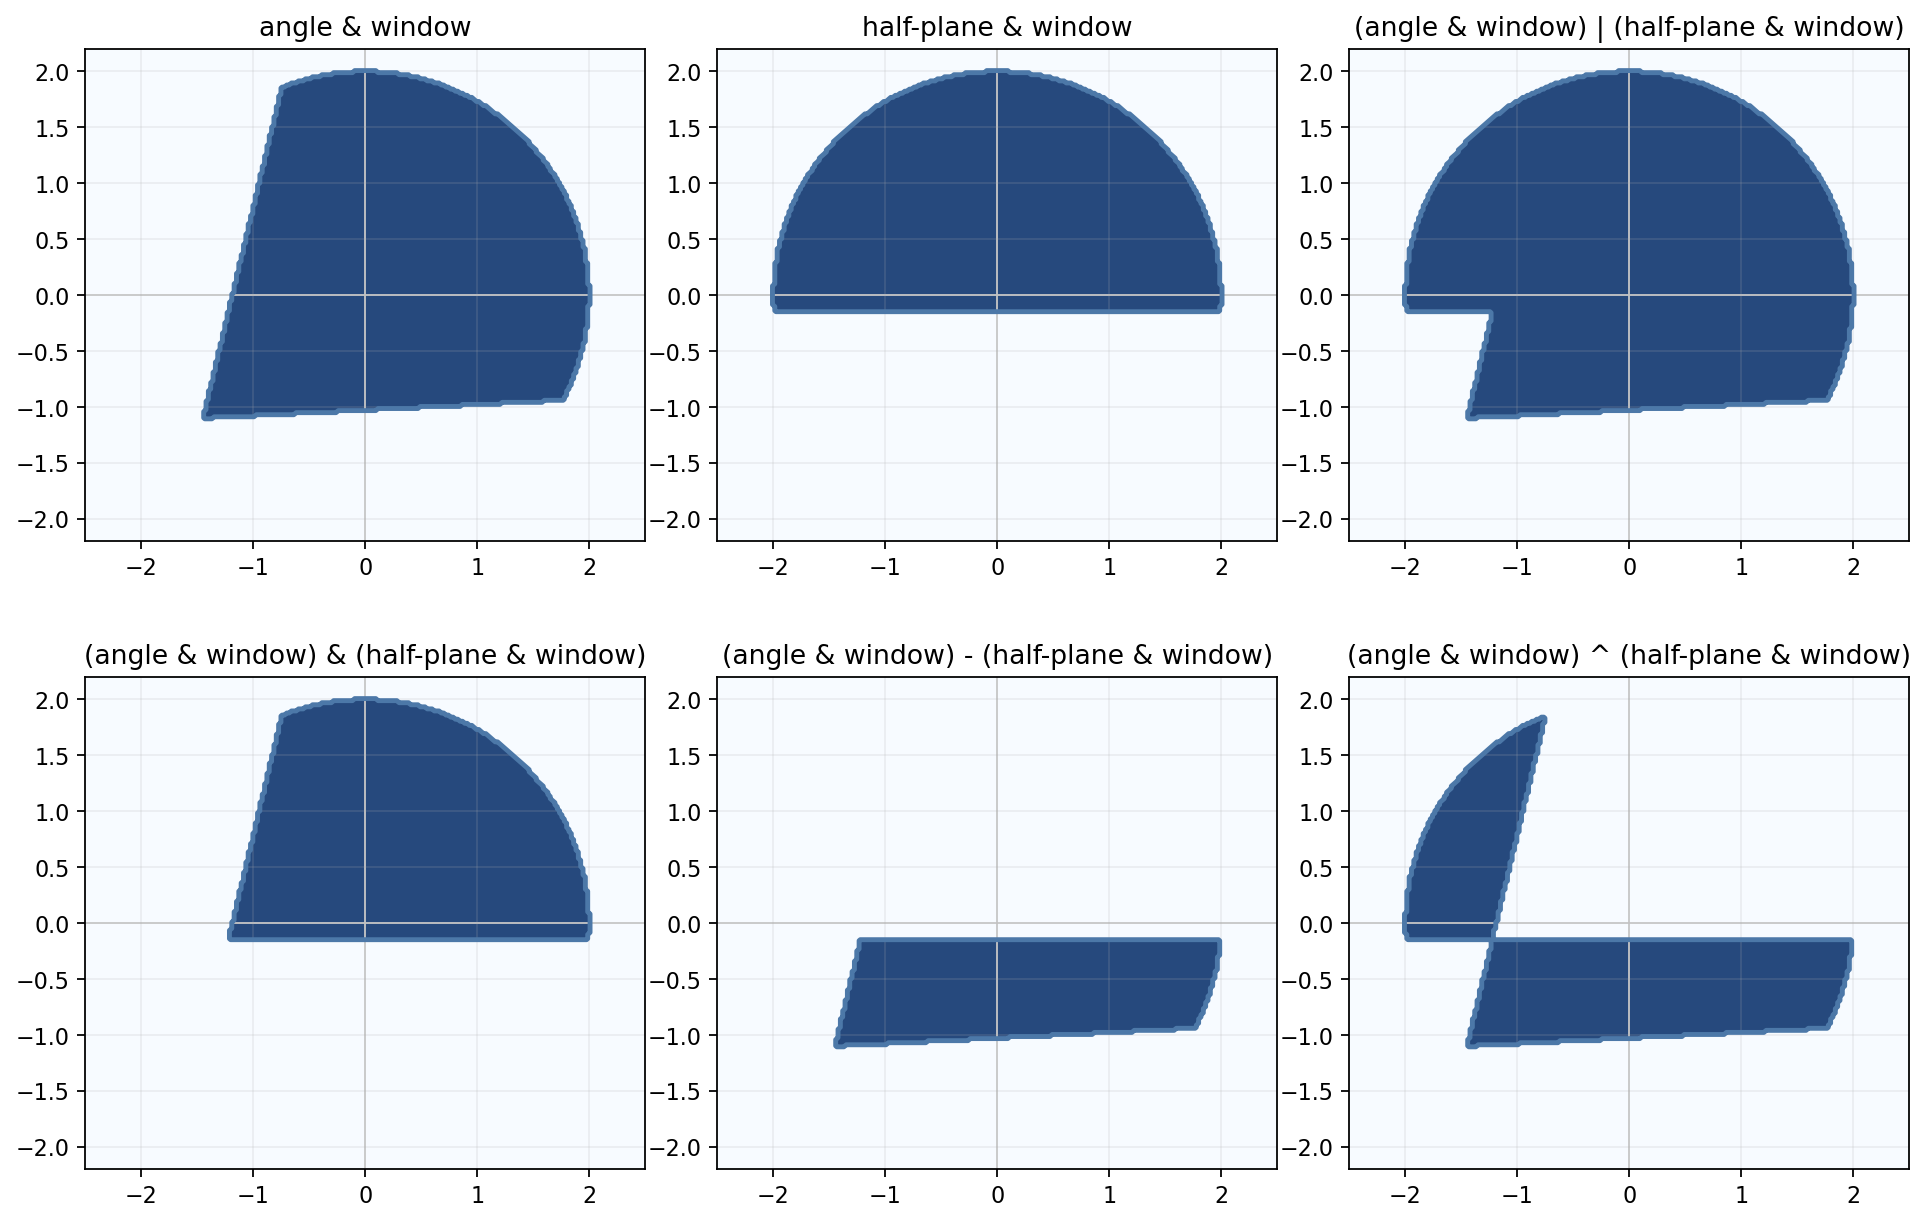

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
plot_object(axes[0, 0], clipped_angle, 'angle & window')
plot_object(axes[0, 1], clipped_half_plane, 'half-plane & window')
plot_object(axes[0, 2], window_union, '(angle & window) | (half-plane & window)')
plot_object(axes[1, 0], window_intersection, '(angle & window) & (half-plane & window)')
plot_object(axes[1, 1], window_difference, '(angle & window) - (half-plane & window)')
plot_object(axes[1, 2], window_xor, '(angle & window) ^ (half-plane & window)')
fig.tight_layout()
fig
